<a href="https://colab.research.google.com/github/konishogu/DeepLearning-SIMPSON/blob/main/DLY01100_EV2_003D_GRUPO_DEEPER_LEANER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



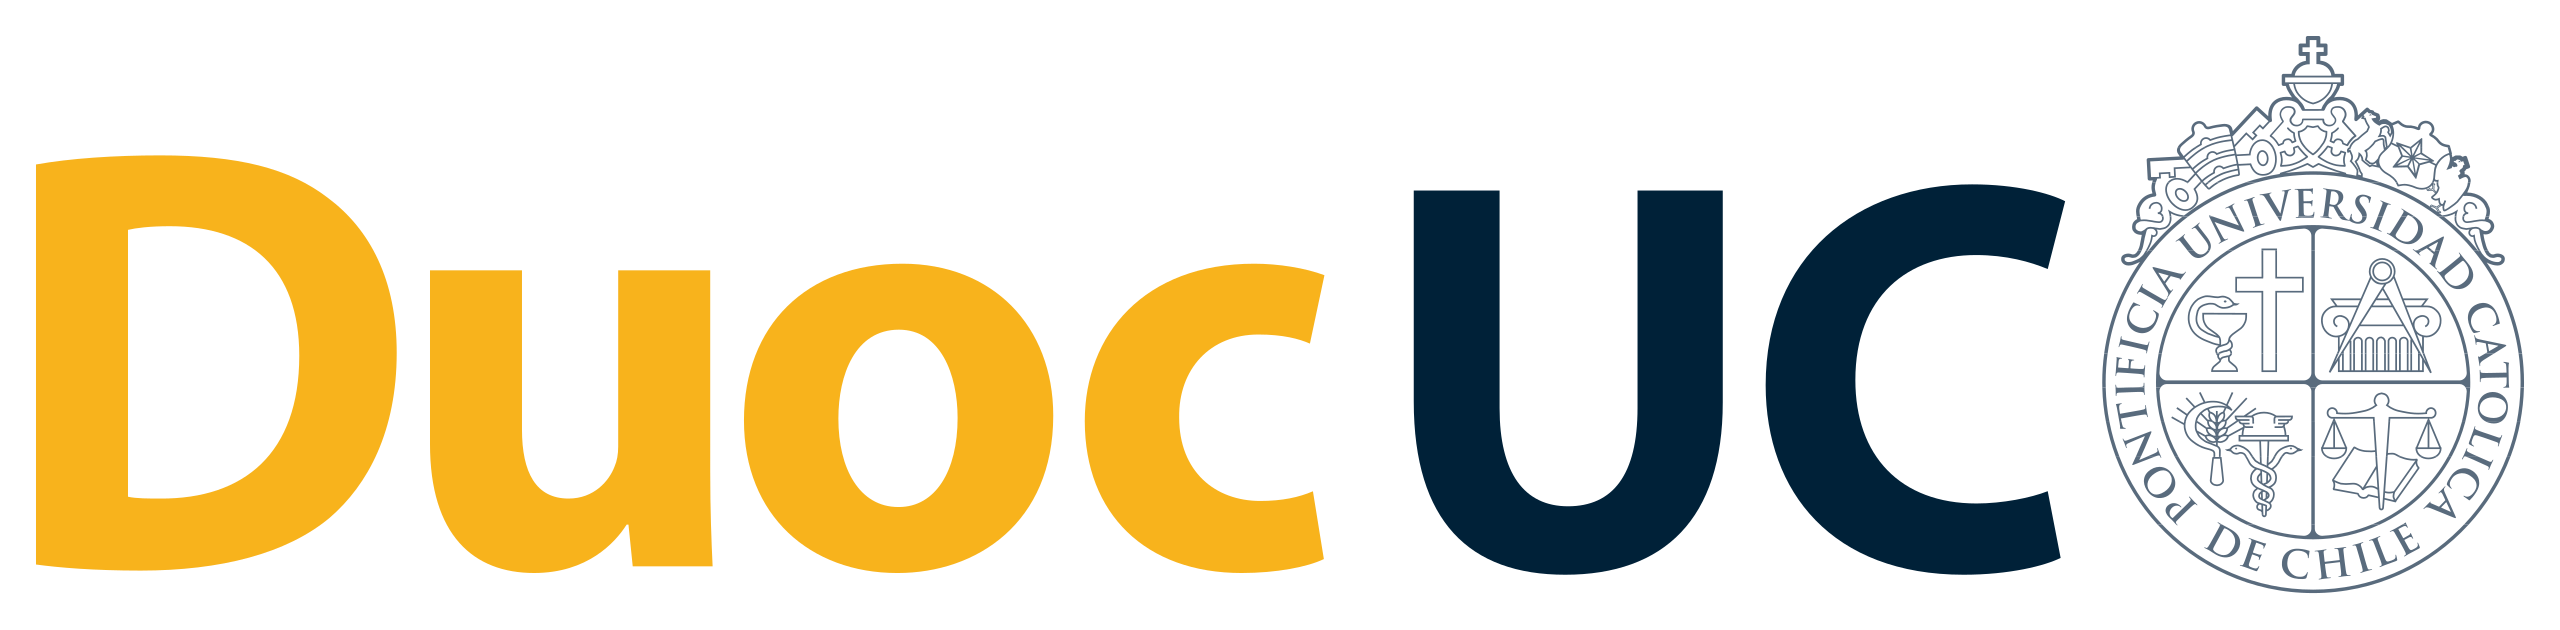



---
**Autores:**

- Matias Ignacio Wastavino Gonzalez
- Luis Rodrigo Nicolas Mendez Lehner
- Rodrigo Antonio Carcamo Rojas
- Matias Ignacio Molina Sepulveda
- Alejandra Ignacia Riquelme Velásquez

**Docente:** Marcelo Alejandro Tapia Contreras

**Asignatura:** Deep learning

**Sección:** 003D

**Institución:** Duoc UC - Sede Melipilla

**Fecha de entrega:** 22 de Mayo de 2026

---

## **1. INTRODUCCIÓN**

Las redes neuronales convolucionales (CNN) representan una de las arquitecturas más utilizadas en tareas de visión computacional y clasificación de imágenes, debido a su capacidad para extraer automáticamente características visuales relevantes. En este trabajo se aborda un problema de clasificación de imágenes utilizando un dataset compuesto por personajes de la serie Los Simpsons. Este conjunto de datos presenta una complejidad mayor en comparación con datasets tradicionales como MNIST o Fashion MNIST, ya que los personajes aparecen en distintas posiciones, poses, escalas e incluso acompañados por otros personajes dentro de la misma imagen. El objetivo principal del trabajo consiste en implementar y optimizar una CNN utilizando TensorFlow/Keras, evaluando distintas arquitecturas e hiperparámetros para alcanzar un rendimiento superior al 85% de accuracy sobre el conjunto de prueba.

<center><img src="https://i.imgur.com/i8zIGqX.jpg" style="text-align: center" height="300px"></center>

## **2. IMPORTACIÓN DE LIBRERÍAS**

En esta sección se importan las librerías necesarias para el desarrollo del proyecto de clasificación de imágenes mediante redes neuronales convolucionales (CNN).

In [1]:
# Librerías para visualización y procesamiento de imágenes
from google.colab.patches import cv2_imshow
import cv2
import os
import glob
import itertools
import collections
import subprocess

# Librerías para manejo numérico y visualización de datos
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# TensorFlow y Keras para construcción de la CNN
import tensorflow as tf
from tensorflow import keras

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras import layers
from tensorflow.keras.layers import (
    Dense,
    Activation,
    Dropout,
    Flatten,
    BatchNormalization,
    MaxPooling2D,
    Conv2D
)

# Herramientas para preprocesamiento y optimización
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam, SGD

# Librerías para evaluación del modelo
from sklearn.metrics import confusion_matrix
from sklearn import metrics
from sklearn.model_selection import train_test_split

## **3. CARGA DEL DATASET**

### **3.1. Creación de directorio**

Antes de descargar el dataset, es necesario crear un directorio de trabajo donde se almacenarán los archivos utilizados durante el desarrollo del proyecto. En Google Colab, el entorno de ejecución es temporal, por lo que cada vez que la máquina virtual se reinicia se eliminan los archivos almacenados anteriormente. Por esta razón, se crea automáticamente la carpeta '/root/.keras/datasets', utilizada por Keras como ubicación estándar para guardar datasets descargados. Esto permite mantener una estructura organizada y asegurar que las imágenes puedan ser encontradas correctamente durante la carga y el entrenamiento del modelo.

In [2]:
# Crea la carpeta donde se almacenarán los datasets descargados
os.makedirs('/root/.keras/datasets', exist_ok=True)

### **3.2. Descarga de datos**

En esta etapa se descargan los archivos comprimidos que contienen el dataset de entrenamiento y prueba utilizado en el proyecto. Para ello se utiliza la herramienta 'gdown', que permite descargar archivos directamente desde Google Drive mediante un identificador único. Los archivos descargados se almacenan en el directorio creado previamente, permitiendo disponer localmente de las imágenes necesarias para el entrenamiento y evaluación de la red neuronal convolucional.

In [3]:
# Descarga el dataset de entrenamiento desde Google Drive y lo guarda en el directorio
print("⬇Descargando simpsons_train.tar.gz ...")
!gdown 1snRV751UeWXFVJVgBvhY2pfiqAx_95yS -O /root/.keras/datasets/simpsons_train.tar.gz

# Descarga el dataset de prueba desde Google Drive y lo guarda en el directorio
print("⬇Descargando simpsons_test.tar.gz ...")
!gdown 1Cu0Z-26STopwxlnZ032Xh1ScDoHk7Zfj -O /root/.keras/datasets/simpsons_test.tar.gz

⬇Descargando simpsons_train.tar.gz ...
Downloading...
From: https://drive.google.com/uc?id=1snRV751UeWXFVJVgBvhY2pfiqAx_95yS
To: /root/.keras/datasets/simpsons_train.tar.gz
100% 10.7M/10.7M [00:00<00:00, 27.5MB/s]
⬇Descargando simpsons_test.tar.gz ...
Downloading...
From (original): https://drive.google.com/uc?id=1Cu0Z-26STopwxlnZ032Xh1ScDoHk7Zfj
From (redirected): https://drive.google.com/uc?id=1Cu0Z-26STopwxlnZ032Xh1ScDoHk7Zfj&confirm=t&uuid=4460ed11-9a5f-4d31-ae37-44d7d1f6768d
To: /root/.keras/datasets/simpsons_test.tar.gz
100% 524M/524M [00:10<00:00, 51.0MB/s]


### **3.3. Descomprensión**

Una vez descargados los archivos comprimidos del dataset, es necesario extraer su contenido para poder acceder a las imágenes utilizadas en el entrenamiento y prueba del modelo. Para ello se utiliza el comando 'tar', el cual descomprime los archivos '.tar.gz' y almacena las carpetas resultantes dentro del directorio de trabajo configurado previamente.

In [4]:
# Descomprime el dataset de entrenamiento dentro del directorio
!tar -xzf /root/.keras/datasets/simpsons_train.tar.gz -C /root/.keras/datasets --ignore-zeros

# Descomprime el dataset de prueba dentro del directorio
!tar -xzf /root/.keras/datasets/simpsons_test.tar.gz -C /root/.keras/datasets --ignore-zeros

### **3.4. Verificación de archivos**

Después de descargar y descomprimir los datasets, se realiza una verificación del contenido almacenado en el directorio de trabajo. Esto permite comprobar que los archivos y carpetas fueron creados correctamente antes de continuar con la carga y procesamiento de imágenes.

In [5]:
# Muestra los archivos y carpetas disponibles dentro del directorio
print("\nContenido descargado:")
!ls /root/.keras/datasets/


Contenido descargado:
simpsons  simpsons_testset  simpsons_test.tar.gz  simpsons_train.tar.gz


### **3.5. Configuración del dataset**

In [6]:
# Mapeo entre etiquetas numéricas y personajes del dataset
MAP_CHARACTERS = {
    0: 'abraham_grampa_simpson', 1: 'apu_nahasapeemapetilon', 2: 'bart_simpson',
    3: 'charles_montgomery_burns', 4: 'chief_wiggum', 5: 'comic_book_guy',
    6: 'edna_krabappel', 7: 'homer_simpson', 8: 'kent_brockman',
    9: 'krusty_the_clown', 10: 'lisa_simpson', 11: 'marge_simpson',
    12: 'milhouse_van_houten', 13: 'moe_szyslak', 14: 'ned_flanders',
    15: 'nelson_muntz', 16: 'principal_skinner', 17: 'sideshow_bob'
}

# Tamaño estándar utilizado para redimensionar todas las imágenes
IMG_SIZE = 64

## **4. CARGA DE IMÁGENES**

### **4.1. Función de carga de entrenamiento**

In [7]:
def load_train_set(dirname, map_characters, verbose=True):

    # Lista donde se almacenarán las imágenes
    X_train = []
    # Lista donde se almacenarán las etiquetas
    y_train = []

    # Recorre cada personaje y su etiqueta numérica
    for label, character in map_characters.items():

        # Obtiene los archivos de la carpeta del personaje
        files = os.listdir(os.path.join(dirname, character))

        # Filtra únicamente imágenes .jpg
        images = [file for file in files if file.endswith("jpg")]
        if verbose:
          print("Leyendo {} imágenes encontradas de {}".format(len(images), character))

        # Recorre cada imagen encontrada
        for image_name in images:

            # Lee la imagen desde el directorio
            image = cv2.imread(os.path.join(dirname, character, image_name))

            # Redimensiona la imagen y la guarda
            X_train.append(cv2.resize(image,(IMG_SIZE, IMG_SIZE)))

            # Guarda la etiqueta correspondiente al personaje
            y_train.append(label)

    # Convierte las listas a arrays NumPy y las retorna
    return np.array(X_train), np.array(y_train)

### **4.2. Función de carga de test**

In [8]:
def load_test_set(dirname, map_characters, verbose=True):

    # Lista donde se almacenarán las imágenes
    X_test = []
    # Lista donde se almacenarán las etiquetas
    y_test = []

    # Invierte el diccionario
    reverse_dict = {v: k for k, v in map_characters.items()}

    # Recorre todos los archivos del directorio
    for filename in glob.glob(dirname + '/*.*'):

        # Extrae el nombre del personaje desde el archivo
        char_name = "_".join(filename.split('/')[-1].split('_')[:-1])

        # Verifica que el personaje exista en el diccionario
        if char_name in reverse_dict:

            # Lee la imagen usando OpenCV
            image = cv2.imread(filename)

            # Redimensiona la imagen al tamaño definido
            image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

            # Guarda la imagen procesada
            X_test.append(image)

            # Guarda la etiqueta correspondiente al personaje
            y_test.append(reverse_dict[char_name])

    if verbose:
        print("Leídas {} imágenes de test".format(len(X_test)))

    # Convierte las listas a arrays NumPy y las retorna
    return np.array(X_test), np.array(y_test)

### **4.3. Carga del dataset en memoria**

In [9]:
# Ruta donde se encuentran las imágenes de entrenamiento
DATASET_TRAIN_PATH_COLAB = "/root/.keras/datasets/simpsons"

# Ruta donde se encuentran las imágenes de test
DATASET_TEST_PATH_COLAB = "/root/.keras/datasets/simpsons_testset"

# Carga las imágenes y etiquetas del conjunto de entrenamiento
X, y = load_train_set(DATASET_TRAIN_PATH_COLAB, MAP_CHARACTERS)

# Carga las imágenes y etiquetas del conjunto de prueba
X_t, y_t = load_test_set(DATASET_TEST_PATH_COLAB, MAP_CHARACTERS)

Leyendo 913 imágenes encontradas de abraham_grampa_simpson
Leyendo 623 imágenes encontradas de apu_nahasapeemapetilon
Leyendo 1342 imágenes encontradas de bart_simpson
Leyendo 1193 imágenes encontradas de charles_montgomery_burns
Leyendo 986 imágenes encontradas de chief_wiggum
Leyendo 469 imágenes encontradas de comic_book_guy
Leyendo 457 imágenes encontradas de edna_krabappel
Leyendo 2246 imágenes encontradas de homer_simpson
Leyendo 498 imágenes encontradas de kent_brockman
Leyendo 1206 imágenes encontradas de krusty_the_clown
Leyendo 1354 imágenes encontradas de lisa_simpson
Leyendo 1291 imágenes encontradas de marge_simpson
Leyendo 1079 imágenes encontradas de milhouse_van_houten
Leyendo 1452 imágenes encontradas de moe_szyslak
Leyendo 1454 imágenes encontradas de ned_flanders
Leyendo 358 imágenes encontradas de nelson_muntz
Leyendo 1194 imágenes encontradas de principal_skinner
Leyendo 877 imágenes encontradas de sideshow_bob
Leídas 890 imágenes de test


### **4.4. Mezcla aleatoria del dataset**

In [10]:
# Genera un orden aleatorio para mezclar las imágenes
perm = np.random.permutation(len(X))

# Reorganiza imágenes y etiquetas manteniendo su correspondencia
X, y = X[perm], y[perm]

## **5. EXPLORACIÓN Y ANÁLISIS DE DATOS**

### **5.1. Ver dimensiones del dataset**

En esta etapa se verifican las dimensiones de los conjuntos de entrenamiento y prueba cargados en memoria. El propósito de este apartado es comprobar que las imágenes y sus etiquetas fueron almacenadas correctamente, asegurando que la cantidad de datos y la estructura de las matrices sean adecuadas para el entrenamiento de la red. Además, esta validación permite detectar posibles inconsistencias antes de continuar con las siguientes secciones.

In [11]:
print(f"------------------------------------------------")
print(f"Imágenes de entrenamiento: {X.shape}")
print(f"------------------------------------------------")
print(f"Etiquetas de entrenamiento: {y.shape}")
print(f"------------------------------------------------")
print(f"Imágenes de prueba: {X_t.shape}")
print(f"------------------------------------------------")
print(f"Etiquetas de prueba: {y_t.shape}")
print(f"------------------------------------------------")

------------------------------------------------
Imágenes de entrenamiento: (18992, 64, 64, 3)
------------------------------------------------
Etiquetas de entrenamiento: (18992,)
------------------------------------------------
Imágenes de prueba: (890, 64, 64, 3)
------------------------------------------------
Etiquetas de prueba: (890,)
------------------------------------------------


**CONCLUSIÓN:** La salida obtenida confirma que el dataset fue cargado correctamente en memoria. El conjunto de entrenamiento contiene 18.992 imágenes con dimensiones de 64x64 píxeles y 3 canales de color RGB, mientras que el conjunto de prueba contiene 890 imágenes con las mismas características. Las etiquetas de entrenamiento y prueba presentan una dimensión de una sola columna, lo que indica que cada imagen posee una clase asociada correspondiente a uno de los personajes del dataset. Además, se verifica que todas las imágenes fueron estandarizadas al mismo tamaño, lo cual es fundamental para el correcto funcionamiento de una CNN, ya que el modelo requiere entradas con dimensiones uniformes durante el proceso de entrenamiento y evaluación.

### **5.2. Mostrar imágenes ejemplo [NO EJECUTAR LA CELDA DE CÓDIGO]**

En esta etapa se realiza una visualización de algunas imágenes pertenecientes al conjunto de entrenamiento. Este proceso permite verificar que las imágenes fueron cargadas correctamente, que las etiquetas coinciden con cada personaje y que el formato de color y dimensiones son adecuados para el procesamiento de la CNN. Además, esta exploración permite observar la variabilidad visual presente en el dataset, identificando diferencias de poses, expresiones, iluminación, tamaños y fondos entre las imágenes. También ayuda a detectar posibles problemas como imágenes corruptas, ruido o similitudes visuales entre personajes, factores que aumentan la complejidad del problema de clasificación.

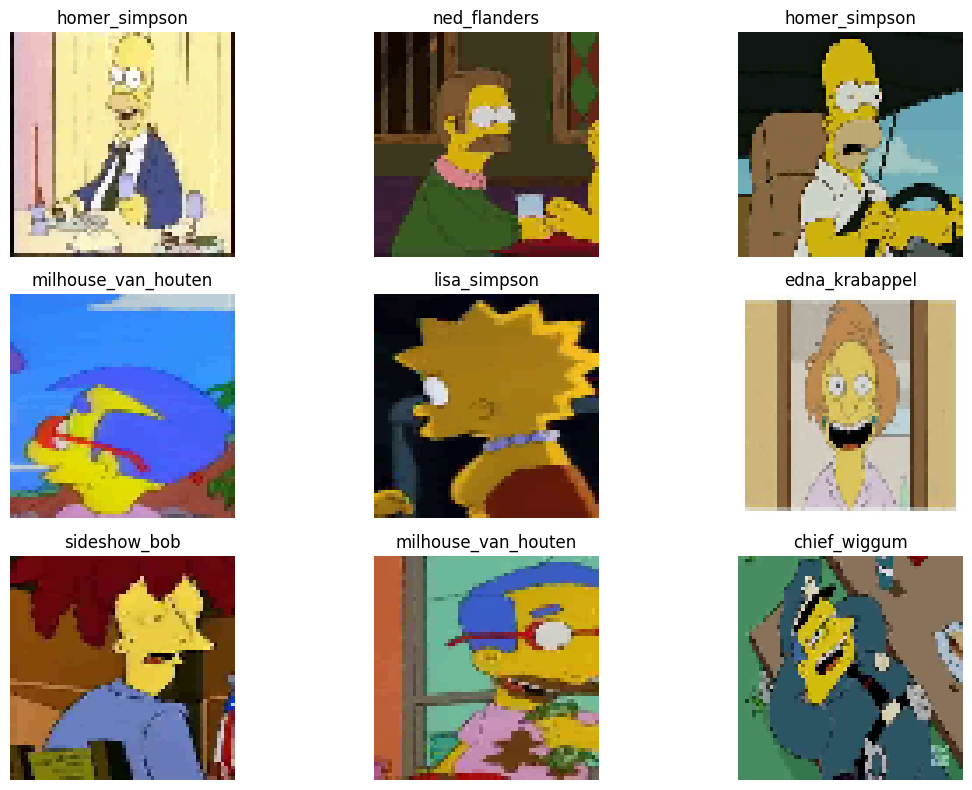

In [12]:
# Crea una figura para visualizar imágenes
plt.figure(figsize=(12,8))

# Recorre las primeras 9 imágenes del dataset
for i in range(9):

    # Organiza las imágenes en una cuadrículas 3x3
    plt.subplot(3,3,i+1)

    # Convierte la imagen de BGR a RGB y la muestra
    plt.imshow(cv2.cvtColor(X[i], cv2.COLOR_BGR2RGB))

    # Obtiene la etiqueta correspondiente
    label = y[i]

    # Muestra el nombre del personaje
    plt.title(MAP_CHARACTERS[label])

    # Oculta los ejes de la imagen
    plt.axis("off")

# Ajusta automáticamente los espacios
plt.tight_layout()

# Muestra la visualización final
plt.show()

**CONCLUSIONES:**

1. Se observan diferencias de poses, ángulos, iluminación, expresiones faciales y fondos. Por ejemplo, Lisa aparece de perfil, mientras que Homer se muestra en dos escenarios distintos y Milhouse cambia de posición y tamaño entre imágenes. Esto implica que la red no puede limitarse a memorizar imágenes específicas, sino que debe aprender patrones generales que permitan reconocer a cada personaje en diferentes contextos.

2. También se identificaron diferencias de escala y encuadre. Algunos personajes ocupan casi toda la imagen, mientras que otros aparecen más alejados o parcialmente visibles. Por ejemplo, Lisa aparece en un primer plano donde su rostro ocupa gran parte del recuadro, mientras que Milhouse y Sideshow Bob aparecen en planos más amplios mostrando parte del cuerpo y la vestimenta. Esta variabilidad aumenta la complejidad del problema, ya que la red debe reconocer personajes aunque cambien de tamaño, posición o no se encuentren centrados en la imagen.

3. Otro aspecto relevante es la similitud visual entre algunos personajes. Muchos comparten colores, estilos de dibujo y rasgos faciales similares. Esto obliga a la red a aprender atributos más específicos, como formas de ojos, peinados, accesorios, contornos y proporciones faciales, evitando depender únicamente del color para clasificar correctamente.

4. Además, el dataset contiene ruido visual. Varias imágenes presentan fondos complejos, objetos adicionales e incluso otros personajes dentro de la escena. Por ejemplo, Ned Flanders en la taberna de Moe o Homer conduciendo, el fondo incorpora múltiples elementos que no aportan directamente a la clasificación. A diferencia de datasets más simples como MNIST, donde el fondo es uniforme, aquí la red debe aprender a distinguir el personaje principal del resto de la escena.

5. Por otra parte, todas las imágenes fueron redimensionadas a 64x64 píxeles. Sin embargo, esta reducción también disminuye el nivel de detalle visual, dificultando la diferenciación entre personajes similares. Debido a esto, la red deberá extraer características relevantes incluso en imágenes de baja resolución.

### **5.3. Distribución de clases**

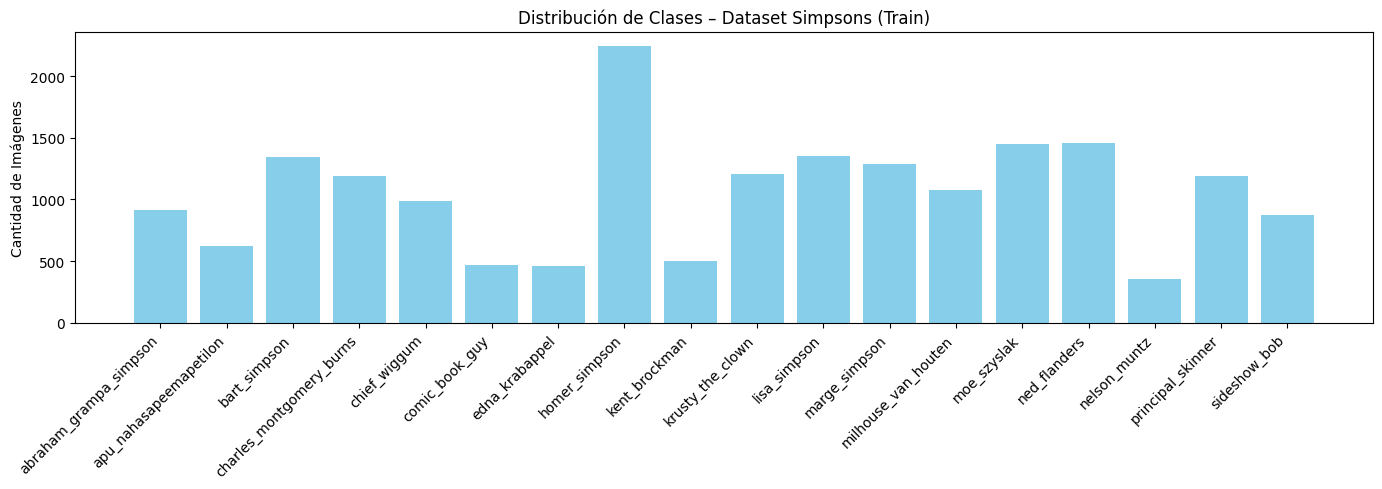

In [21]:
unique, counts = np.unique(y, return_counts=True)

labels = [MAP_CHARACTERS[i] for i in unique]
plt.figure(figsize=(14, 5))
plt.bar(labels, counts, color='skyblue')
plt.title("Distribución de Clases – Dataset Simpsons (Train)")
plt.ylabel("Cantidad de Imágenes")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## **6. PREPROCESAMIENTO**

In [ ]:
X = X.astype('float32') / 255.0
X_t = X_t.astype('float32') / 255.0

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [ ]:
y_train_cat = keras.utils.to_categorical(y_train, 18)
y_val_cat = keras.utils.to_categorical(y_val, 18)
y_test_cat = keras.utils.to_categorical(y_t, 18)

In [ ]:
datagen = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

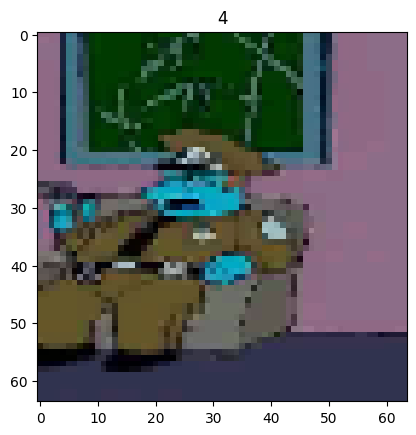

In [ ]:
plt.imshow(X_train[0])
plt.title(y_train[0])
plt.show()

## **8. MODELO 1 - CNN BASE**

In [ ]:
model_base = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),

    Dense(18, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model_base.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_base = model_base.fit(
    X_train,
    y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=15,
    batch_size=32
)

Epoch 1/15
475/475 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.4630 - loss: 1.7975 - val_accuracy: 0.6146 - val_loss: 1.3031
Epoch 2/15
475/475 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6957 - loss: 1.0405 - val_accuracy: 0.7026 - val_loss: 1.0187
Epoch 3/15
475/475 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8043 - loss: 0.6664 - val_accuracy: 0.7428 - val_loss: 0.8827
Epoch 4/15
475/475 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8853 - loss: 0.3926 - val_accuracy: 0.7860 - val_loss: 0.8238
Epoch 5/15
475/475 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9452 - loss: 0.1952 - val_accuracy: 0.7739 - val_loss: 0.9381
Epoch 6/15
475/475 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9750 - loss: 0.0958 - val_accuracy: 0.7691 - val_loss: 1.0000
Epoch 7/15
475/475 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9889 - loss: 0.0487 - val_accuracy: 0.7799 - val_loss: 1.1252
Epoch 8/15
475/475 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9848 - loss: 0.0534 - val_accuracy: 

In [ ]:
model_base.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 18)             │         2,322 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,882,424 (18.62 MB)

 Trainable params: 1,627,474 (6.21 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,254,950 (12.42 MB)

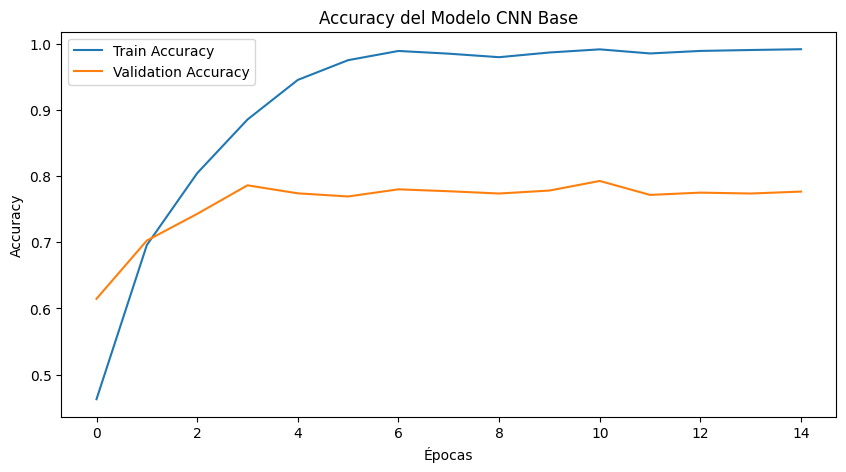

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history_base.history['accuracy'], label='Train Accuracy')
plt.plot(history_base.history['val_accuracy'], label='Validation Accuracy')

plt.title('Accuracy del Modelo CNN Base')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

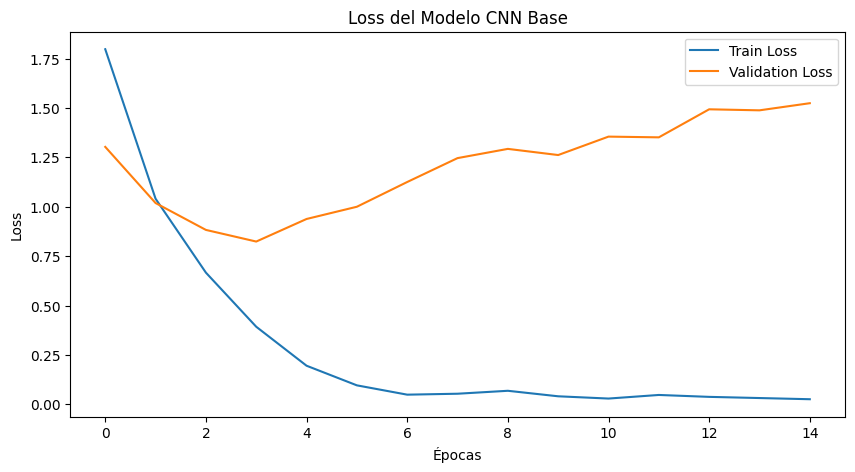

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history_base.history['loss'], label='Train Loss')
plt.plot(history_base.history['val_loss'], label='Validation Loss')

plt.title('Loss del Modelo CNN Base')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [ ]:
y_pred_probs = model_base.predict(X_t)
y_pred = np.argmax(y_pred_probs, axis=1)

28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_t,
    y_pred,
    target_names=list(MAP_CHARACTERS.values())
))

                          precision    recall  f1-score   support

  abraham_grampa_simpson       0.87      0.94      0.90        48
  apu_nahasapeemapetilon       0.93      1.00      0.96        50
            bart_simpson       0.87      0.94      0.90        50
charles_montgomery_burns       0.98      0.83      0.90        48
            chief_wiggum       1.00      0.96      0.98        50
          comic_book_guy       1.00      0.92      0.96        49
          edna_krabappel       0.98      0.92      0.95        50
           homer_simpson       0.82      0.94      0.88        50
           kent_brockman       0.98      0.92      0.95        50
        krusty_the_clown       0.98      0.96      0.97        50
            lisa_simpson       0.90      0.88      0.89        50
           marge_simpson       0.94      0.98      0.96        50
     milhouse_van_houten       0.94      0.96      0.95        49
             moe_szyslak       0.96      0.96      0.96        50
         

## **9. COMPARACIÓN DE MODELOS (EN PROCESO)**

## **10. EVALUACIÓN DEL MEJOR MODELO**

## **11. JUSTIFICACIÓN DEL MODELO FINAL**

## **12. CONCLUSIÓN**